In [ ]:


url = "https://www.tefas.gov.tr/api/DB/BindHistoryInfo"
headers = {
    "Content-Type": "application/json"
}
payload = {
    "bastarih": "14.08.2020",
    "bittarih": "14.08.2020",
    "fontip": "YAT"
}

r = requests.post(url, json=payload, headers=headers)
print(r.json())

In [2]:
import os
import time
import requests
import random
import pandas as pd

BASE_URLS = {
    "menkul_genel": "https://www.tefas.gov.tr/api/DB/BindHistoryInfo",
    "menkul_portfoy": "https://www.tefas.gov.tr/api/DB/BindHistoryAllocation",
    "emekli_genel": "https://www.tefas.gov.tr/api/DB/BindHistoryInfo",
    "emekli_portfoy": "https://www.tefas.gov.tr/api/DB/BindHistoryAllocation"
}

def fetch_and_save(date):
    save_path = os.path.join(os.path.expanduser("~"), "Desktop", "tefas")
    os.makedirs(save_path, exist_ok=True)

    for name, url in BASE_URLS.items():
        # Burada gerekli payload/query param eklenmeli (tarih vs.)
        tip='YAT'
        if name[0] == 'e':
            tip = 'EMK'
                
        headers = {
            "Content-Type": "application/json"
        }
        payload = {
            "bastarih": date,
            "bittarih": date,
            "fontip": tip
        }
        r = requests.post(url, json=payload, headers=headers)
        data = r.json()["data"]
        if r.json()['recordsTotal'] > 0:
            df = pd.DataFrame(data)
            df.to_parquet(f"{save_path}/{name}_{date}.parquet", index=False)
        time.sleep(random.uniform(2, 5))  # güvenli çağrı aralığı

# Örnek: geçmiş 5 yıl için (2020-01-01'den bugüne)
import pandas as pd
dates = pd.date_range("09.15.2025", "09.28.2025", freq="D")
for d in dates:
    fetch_and_save(d.strftime("%d.%m.%Y"))


In [89]:
dates = pd.date_range("08.25.2025", "09.13.2025", freq="D")
for d in dates:
    fetch_and_save(d.strftime("%d.%m.%Y"))


In [35]:
file_path = os.path.join(os.path.expanduser("~"), "Desktop", "tefas", "menkul_genel_22.08.2025.parquet")
df = pd.read_parquet(file_path)
df.head()

,TARIH,FONKODU,FONUNVAN,FIYAT,TEDPAYSAYISI,KISISAYISI,PORTFOYBUYUKLUK,BORSABULTENFIYAT
0,1755820800000,AAK,ATA PORTFÖY ÇOKLU VARLIK DEĞİŞKEN FON,28.590491,1.230079e+06,757.0,3.516856e+07,-
1,1755820800000,AAL,ATA PORTFÖY PARA PİYASASI (TL) FONU,2.437561,1.189667e+09,5033.0,2.899885e+09,-
2,1755820800000,AAS,ATA PORTFÖY FON SEPETİ SERBEST FONU,9.130278,4.400635e+06,151.0,4.017902e+07,-
3,1755820800000,AAV,ATA PORTFÖY İKİNCİ HİSSE SENEDİ (TL) FONU (HİS...,52.277919,1.739099e+07,3394.0,9.091647e+08,-
4,1755820800000,ABG,ATLAS PORTFÖY DÖRDÜNCÜ SERBEST (TL) FON,9.354563,1.063472e+08,14.0,9.948312e+08,-


In [37]:
import re

pattern = r"(?:DÖVİZ|YABANCI|KIYMETLİ|GÜMÜŞ|ALTIN\s)"

filtered_df = df[df["FONUNVAN"].str.contains(pattern, flags=re.IGNORECASE, regex=True)]

filtered_df.head()

,TARIH,FONKODU,FONUNVAN,FIYAT,TEDPAYSAYISI,KISISAYISI,PORTFOYBUYUKLUK,BORSABULTENFIYAT
9,1755820800000,ACN,İSTANBUL PORTFÖY LİDYA SERBEST (DÖVİZ) FON,10.407469,7.382029e+07,21.0,7.682824e+08,-
10,1755820800000,ACU,İSTANBUL PORTFÖY URARTU SERBEST (DÖVİZ) FON,45.817385,2.788624e+07,144.0,1.277675e+09,-
13,1755820800000,AC3,PARDUS PORTFÖY ÜÇÜNCÜ SERBEST (DÖVİZ) FON,59.989414,2.090209e+06,14.0,1.253904e+08,-
16,1755820800000,AC6,PARDUS PORTFÖY DÖRDÜNCÜ SERBEST (DÖVİZ) FON,49.866200,1.558027e+06,141.0,7.769289e+07,-
22,1755820800000,AES,AK PORTFÖY PETROL YABANCI BYF FON SEPETİ FONU,0.097246,7.897838e+09,30763.0,7.680316e+08,-


In [52]:
filtered_df[["FONKODU", "FIYAT", "TEDPAYSAYISI"]]

,FONKODU,FIYAT,TEDPAYSAYISI
9,ACN,10.407469,7.382029e+07
10,ACU,45.817385,2.788624e+07
13,AC3,59.989414,2.090209e+06
16,AC6,49.866200,1.558027e+06
22,AES,0.097246,7.897838e+09
...,...,...,...
1838,ZP9,51.318569,2.973875e+07
1842,ZSF,49.632920,9.920540e+05
1844,ZSK,46.267364,1.054922e+07
1845,ZSN,45.215104,1.372782e+08


In [ ]:
import pandas as pd
def fileopener(str mmddyy):
    e


In [ ]:
df.columns.tolist()

In [63]:
augdf = pd.DataFrame()

In [98]:
import os
import pandas as pd
import numpy as np

# 📂 Dosya yolu ayarları
base_path = os.path.join(os.path.expanduser("~"), "Desktop", "tefas")

# 📅 Tüm günler (hafta sonu / tatil fark etmeksizin)
dates = pd.date_range(start="2025-08-01", end="2025-09-13", freq="D")

# 📝 Fon isimlerinde aranacak kelimeler
pattern = r"\b(?:DÖVİZ|YABANCI|KIYMETLİ|GÜMÜŞ|ALTIN\s)\b"

# 📊 Sonuçları tutacağımız liste
daily_inflows = []

prev_df = None

for date in dates:
    file_name = f"menkul_genel_{date.strftime('%d.%m.%Y')}.parquet"
    file_path = os.path.join(base_path, file_name)
    
    if not os.path.exists(file_path):
        continue  # Dosya yoksa atla, o günü iş günü sayma
    
    # 📥 Günlük veriyi oku
    df = pd.read_parquet(file_path)
    
    # 🎯 Fon isimlerinde filtre
    df_filtered = df[df["FONUNVAN"].str.contains(pattern, flags=re.IGNORECASE, regex=True)]
    
    # Sadece gerekli kolonlar
    df_filtered = df_filtered[["FONKODU", "FIYAT", "TEDPAYSAYISI"]]
    
    if prev_df is not None:
        # 🔗 Fon kodu üzerinde birleştir
        merged = pd.merge(df_filtered, prev_df, on="FONKODU", how="left", suffixes=("", "_prev"))
        
        # TEDPAYSAYISI farkı * 2. gün FIYAT
        merged["giris"] = (merged["TEDPAYSAYISI"] - merged["TEDPAYSAYISI_prev"].fillna(0)) * merged["FIYAT"]
        
        if date.strftime('%Y-%m-%d') == '2025-08-06':
            augdf = merged
        # O günkü toplam giriş
        total_inflow = merged["giris"].sum()
        daily_inflows.append({"tarih": date, "toplam_giris": total_inflow})
    
    # Sonraki döngü için bugünkü dataframe'i sakla
    prev_df = df_filtered.copy()

# 📈 Sonuç DataFrame'i
inflows_df = pd.DataFrame(daily_inflows)


In [96]:
augdf.sort_values(by="giris", ascending=True).head(50)

,FONKODU,FIYAT,TEDPAYSAYISI,FIYAT_prev,TEDPAYSAYISI_prev,giris
580,ZUS,41.617252,4.177491e+08,41.604464,8.074420e+08,-1.621795e+10
534,YP4,44.616342,2.632493e+09,44.599978,2.651930e+09,-8.672213e+08
521,YJY,47.258871,7.848443e+08,47.244879,7.895668e+08,-2.231763e+08
470,TB9,44.005864,8.877741e+08,43.991796,8.920200e+08,-1.868462e+08
518,YDZ,44.596010,3.307115e+08,44.581298,3.343129e+08,-1.606088e+08
204,GPL,43.646516,2.097675e+09,43.633680,2.101143e+09,-1.513620e+08
347,KZL,18.324162,2.297641e+09,18.227011,2.303547e+09,-1.082306e+08
560,ZFZ,55.178407,5.554399e+08,55.131562,5.572849e+08,-1.018042e+08
397,OJK,8.809880,2.683264e+09,8.764255,2.693726e+09,-9.216674e+07
103,DSV,41.017936,5.029485e+06,41.010466,6.879428e+06,-7.588084e+07


In [92]:
inflows_df

,tarih,toplam_giris
0,2020-08-24,3.268550e+06
1,2020-08-25,-1.087288e+08
2,2020-08-26,1.389061e+08
3,2020-08-27,3.464324e+07
4,2020-08-28,-1.906538e+08
...,...,...
1172,2025-09-08,4.531746e+09
1173,2025-09-09,1.331769e+10
1174,2025-09-10,6.843862e+09
1175,2025-09-11,7.773819e+09


In [84]:
new_df = inflows_df.tail(30)

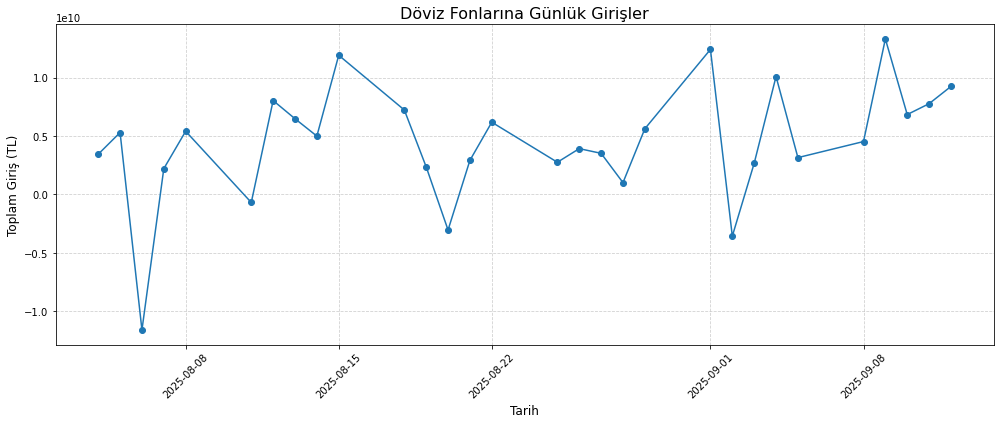

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import os


# Grafik çizimi
plt.figure(figsize=(14, 6))
plt.plot(inflows_df["tarih"], inflows_df["toplam_giris"], marker="o", linewidth=1.5)
plt.title("Döviz Fonlarına Günlük Girişler", fontsize=16)
plt.xlabel("Tarih", fontsize=12)
plt.ylabel("Toplam Giriş (TL)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

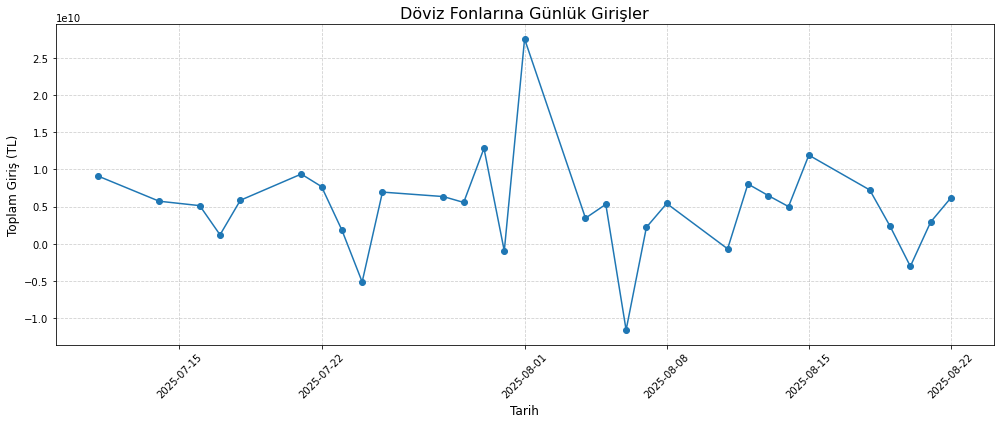

In [85]:
plt.figure(figsize=(14, 6))
plt.plot(new_df["tarih"], new_df["toplam_giris"], marker="o", linewidth=1.5)
plt.title("Döviz Fonlarına Günlük Girişler", fontsize=16)
plt.xlabel("Tarih", fontsize=12)
plt.ylabel("Toplam Giriş (TL)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()